In [7]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import preprocessing
importlib.reload(preprocessing)
from matplotlib import rc
rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 

In [9]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [10]:
# Amount 피처 log1p + StandardScaled

from sklearn.preprocessing import StandardScaler


# Amount 로그 변환 + StandardScaler 적용
df['Amount_log'] = np.log1p(df['Amount'])   # log(Amount+1)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount_log'].values.reshape(-1, 1))

# 원본 Amount, Amount_log 제거
df = df.drop(['Amount', 'Amount_log'], axis=1)

In [11]:
# 특성과 타겟 분리 (Time 컬럼 제거)
X_features, y_target = pp.split_features_target(df, cols='Time')

# 학습/테스트 분할
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [12]:
# baseline 성능 확인
lr_best_params = {
    "random_state": 23,
    'C': 0.029,
    'max_iter': 1000,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    "n_jobs": -1
}

# GradientBoostingClassifier 기본 파라미터
gb_basic_params = {
    'n_estimators': 100,      # 트리 개수 (더 많을수록 성능↑, 시간↑)
    'learning_rate': 0.1,     # 학습률 (0.01~0.3, 작을수록 안정적)
    'max_depth': 3,           # 개별 트리 깊이 (3~5 권장, 과적합 방지)
    'random_state': 23
}

# DecisionTreeClassifier 기본 파라미터
dt_basic_params = {
    'criterion': 'gini',      # 분할 기준 ('gini' 또는 'entropy')
    'max_depth': None,        # 트리 최대 깊이 (None=제한없음, 과적합 위험)
    'random_state': 23
}

# MLPClassifier 기본 파라미터
mlp_basic_params = {
    'hidden_layer_sizes': (64, 32),  # 은닉층 구조 (64개 노드 → 32개 노드)
    'activation': 'relu',             # 활성화 함수 (relu, tanh, logistic)
    'solver': 'adam',                 # 최적화 알고리즘 (adam, sgd, lbfgs)
    'alpha': 1e-4,                    # L2 정규화 파라미터 (과적합 방지)
    'batch_size': 256,                # 배치 크기 (메모리 허용 범위 내 크게)
    'learning_rate': 'adaptive',      # 학습률 스케줄 (adaptive, constant, invscaling)
    'max_iter': 50,                   # 최대 반복 횟수 (early stopping 권장)
    'random_state': 23
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# 1. Logistic Regression
model_name = 'LogReg_Amount_Timedrop__2025_11_27'
lr_clf = LogisticRegression(**lr_best_params)
uu.get_model_train_eval(lr_clf, model_name, X_train, X_test, y_train, y_test)

# 2. Gradient Boosting
model_name = 'GradientBoosting_Amount_Timedrop__2025_11_27'
gb_clf = GradientBoostingClassifier(**gb_basic_params)
uu.get_model_train_eval(gb_clf, model_name, X_train, X_test, y_train, y_test)

# 3. Decision Tree
model_name = 'DecisionTree_Amount_Timedrop__2025_11_27'
dt_clf = DecisionTreeClassifier(**dt_basic_params)
uu.get_model_train_eval(dt_clf, model_name, X_train, X_test, y_train, y_test)

# 4. MLP (Multi-Layer Perceptron)
model_name = 'MLP_Amount_Timedrop__2025_11_27'
mlp_clf = MLPClassifier(**mlp_basic_params)
uu.get_model_train_eval(mlp_clf, model_name, X_train, X_test, y_train, y_test)


results ='''
✓ 모델 저장 완료: ../models\LogReg_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9590, 정확도: 0.9753, 정밀도: 0.0581, 재현율: 0.8776, F1: 0.1089
오차행렬:
[[55469  1395]
 [   12    86]]
실행 시간: 3.593441963195801
✓ 모델 저장 완료: ../models\GradientBoosting_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 295.04548358917236
✓ 모델 저장 완료: ../models\DecisionTree_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.110999584197998
✓ 모델 저장 완료: ../models\MLP_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9638, 정확도: 0.9996, 정밀도: 0.9205, 재현율: 0.8265, F1: 0.8710
오차행렬:
[[56857     7]
 [   17    81]]
실행 시간: 24.000775575637817
'''

✓ 모델 저장 완료: ../models\LogReg_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9590, 정확도: 0.9753, 정밀도: 0.0581, 재현율: 0.8776, F1: 0.1089
오차행렬:
[[55469  1395]
 [   12    86]]
실행 시간: 3.593441963195801
✓ 모델 저장 완료: ../models\GradientBoosting_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 295.04548358917236
✓ 모델 저장 완료: ../models\DecisionTree_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.110999584197998
✓ 모델 저장 완료: ../models\MLP_Amount_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9638, 정확도: 

In [17]:
rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

results = [
    {
        "model": "LogisticRegression",
        "AUC": 0.9590,
        "Accuracy": 0.9753,
        "Precision": 0.0581,
        "Recall": 0.8776,
        "F1": 0.1089,
        "Time": 3.59
    },
    {
        "model": "GradientBoosting",
        "AUC": 0.2959,
        "Accuracy": 0.9985,
        "Precision": 0.7308,
        "Recall": 0.1939,
        "F1": 0.3065,
        "Time": 295.05
    },
    {
        "model": "DecisionTree",
        "AUC": 0.8927,
        "Accuracy": 0.9993,
        "Precision": 0.7857,
        "Recall": 0.7857,
        "F1": 0.7857,
        "Time": 20.11
    },
    {
        "model": "MLPClassifier",
        "AUC": 0.9638,
        "Accuracy": 0.9996,
        "Precision": 0.9205,
        "Recall": 0.8265,
        "F1": 0.8710,
        "Time": 24.00
    }
]

results_df = pd.DataFrame(results).set_index("model")

print("\n=== 모델 성능 비교 결과 ===")
print(results_df)


=== 모델 성능 비교 결과 ===
                       AUC  Accuracy  Precision  Recall      F1    Time
model                                                                  
LogisticRegression  0.9590    0.9753     0.0581  0.8776  0.1089    3.59
GradientBoosting    0.2959    0.9985     0.7308  0.1939  0.3065  295.05
DecisionTree        0.8927    0.9993     0.7857  0.7857  0.7857   20.11
MLPClassifier       0.9638    0.9996     0.9205  0.8265  0.8710   24.00


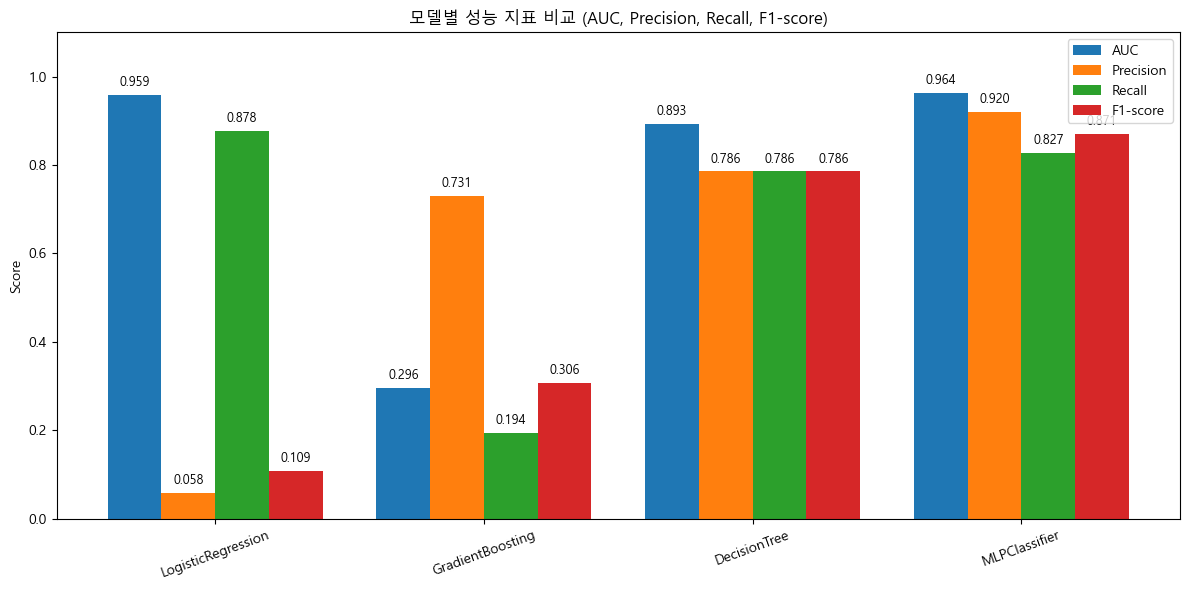

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
models = ["LogisticRegression", "GradientBoosting", "DecisionTree", "MLPClassifier"]

AUC = [0.9590, 0.2959, 0.8927, 0.9638]
precision = [0.0581, 0.7308, 0.7857, 0.9205]
recall = [0.8776, 0.1939, 0.7857, 0.8265]
f1_scores = [0.1089, 0.3065, 0.7857, 0.8710]

# 지표 묶기
metrics = [AUC, precision, recall, f1_scores]
metric_names = ["AUC", "Precision", "Recall", "F1-score"]

# 위치 설정
x = np.arange(len(models))  # 모델 개수만큼 x축 위치
width = 0.2                 # 막대 너비

# 그래프 그리기
plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, metric, width, label=metric_names[i])

# x축 설정
plt.xticks(x + width*1.5, models, rotation=20)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("모델별 성능 지표 비교 (AUC, Precision, Recall, F1-score)")
plt.legend()

# 값 표시
for i, metric in enumerate(metrics):
    for j, v in enumerate(metric):
        plt.text(x[j] + i*width, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

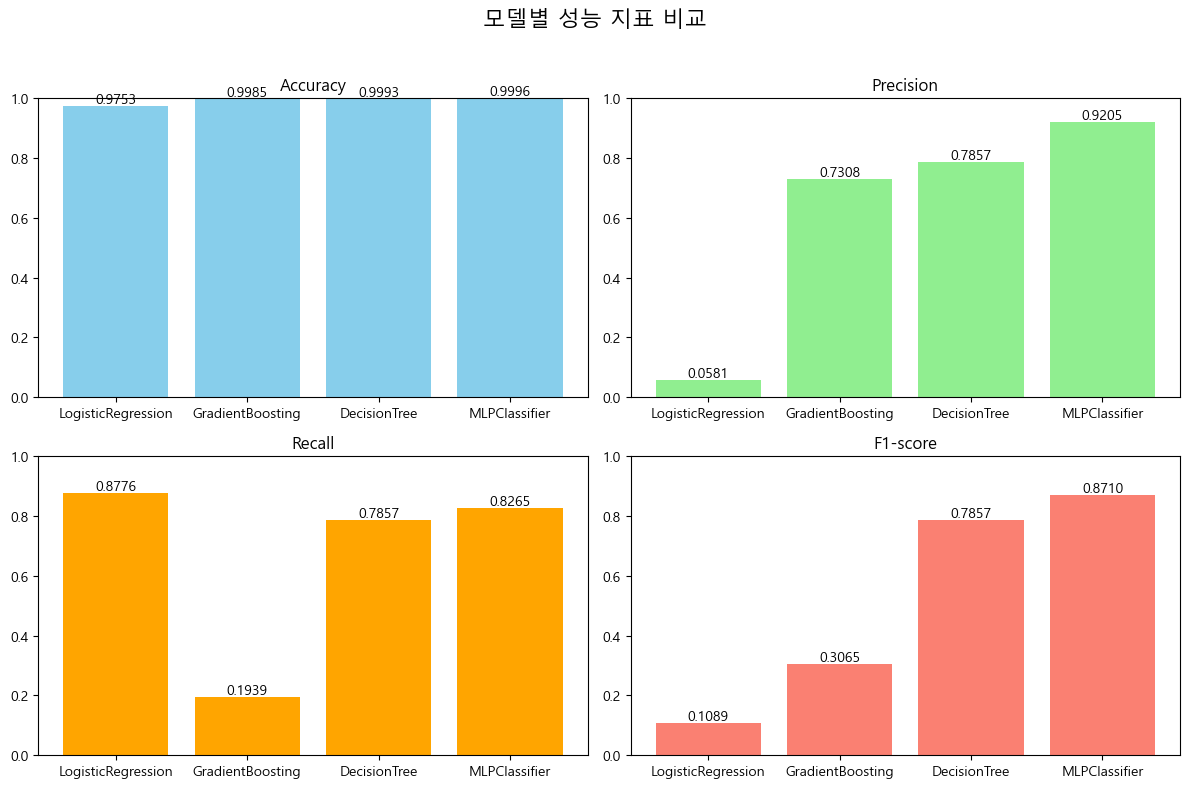

In [18]:
import matplotlib.pyplot as plt

# 데이터 준비
models = ["LogisticRegression", "GradientBoosting", "DecisionTree", "MLPClassifier"]

accuracy = [0.9753, 0.9985, 0.9993, 0.9996]
precision = [0.0581, 0.7308, 0.7857, 0.9205]
recall = [0.8776, 0.1939, 0.7857, 0.8265]
f1_scores = [0.1089, 0.3065, 0.7857, 0.8710]

# 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("모델별 성능 지표 비교", fontsize=16)

# Accuracy
axes[0, 0].bar(models, accuracy, color='skyblue')
axes[0, 0].set_title("Accuracy")
axes[0, 0].set_ylim(0, 1.0)
for i, v in enumerate(accuracy):
    axes[0, 0].text(i, v + 0.01, f"{v:.4f}", ha='center')

# Precision
axes[0, 1].bar(models, precision, color='lightgreen')
axes[0, 1].set_title("Precision")
axes[0, 1].set_ylim(0, 1.0)
for i, v in enumerate(precision):
    axes[0, 1].text(i, v + 0.01, f"{v:.4f}", ha='center')

# Recall
axes[1, 0].bar(models, recall, color='orange')
axes[1, 0].set_title("Recall")
axes[1, 0].set_ylim(0, 1.0)
for i, v in enumerate(recall):
    axes[1, 0].text(i, v + 0.01, f"{v:.4f}", ha='center')

# F1-score
axes[1, 1].bar(models, f1_scores, color='salmon')
axes[1, 1].set_title("F1-score")
axes[1, 1].set_ylim(0, 1.0)
for i, v in enumerate(f1_scores):
    axes[1, 1].text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()